In [ ]:
import numpy as np 
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

from astropy.io import fits

def load_goodss(ID):
    """ Load CANDELS GOODS South photometry from the Guo et al. (2013) catalogue. """

    # load up the relevant columns from the catalogue.
    cat = np.loadtxt(r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\hlsp_candels_hst_wfc3_goodss-tot-multiband_f160w_v1-1photom_cat.txt",
                     usecols=(10, 13, 16, 19, 25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55,
                              11, 14, 17, 20, 26, 29, 32, 35, 38, 41, 44, 47, 50, 53, 56))
    
    # Find the correct row for the object we want.
    row = int(ID) - 1

    # Extract the object we want from the catalogue.
    fluxes = cat[row, :15]
    fluxerrs = cat[row, 15:]

    # Turn these into a 2D array.
    photometry = np.c_[fluxes, fluxerrs]

    # blow up the errors associated with any missing fluxes.
    for i in range(len(photometry)):
        if (photometry[i, 0] == 0.) or (photometry[i, 1] <= 0):
            photometry[i,:] = [0., 9.9*10**99.]
            
    # Enforce a maximum SNR of 20, or 10 in the IRAC channels.
    for i in range(len(photometry)):
        if i < 10:
            max_snr = 20.
            
        else:
            max_snr = 10.
        
        if photometry[i, 0]/photometry[i, 1] > max_snr:
            photometry[i, 1] = photometry[i, 0]/max_snr

    return photometry


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [ ]:
base = (
    r"D:/Users/Abigail Crowther/Desktop/Uni/Year 4/"
    r"MPhys Projects/Semester 2 - Star Formation Histories/"
    r"star-formation-histories/bagpipes/examples"
)

rel_filters = np.loadtxt(
    base + "/filters/goodss_filt_list.txt",
    dtype="str"
)

goodss_filt_list = [base + "/" + f for f in rel_filters]

galaxy = pipes.galaxy("17433", load_goodss, spectrum_exists=False, filt_list=goodss_filt_list)


In [ ]:
sfh = {}
sfh["type"] = "nonparametric"

# Bin edges in Gyr before observation
sfh["age_bins"] = [0.0, 0.1, 0.5, 1.0, 3.0, 13.6]

# Prior on mass formed in each bin (log10 Msun)
sfh["massformed"] = [0., 12.]

In [ ]:
model_components = {
    "redshift": 1.0,  # within CANDELS GOODS-S
    "dust": {"type": "Calzetti", "Av": 0.2},
    "burst": {
        "age": 0.5,        # Gyr before observation
        "massformed": 9.0, # log10(M*/Msun)
        "metallicity": 0.5
    }
}


In [ ]:
galaxy.model = pipes.model_galaxy(
    model_components,
    filt_list=goodss_filt_list
)

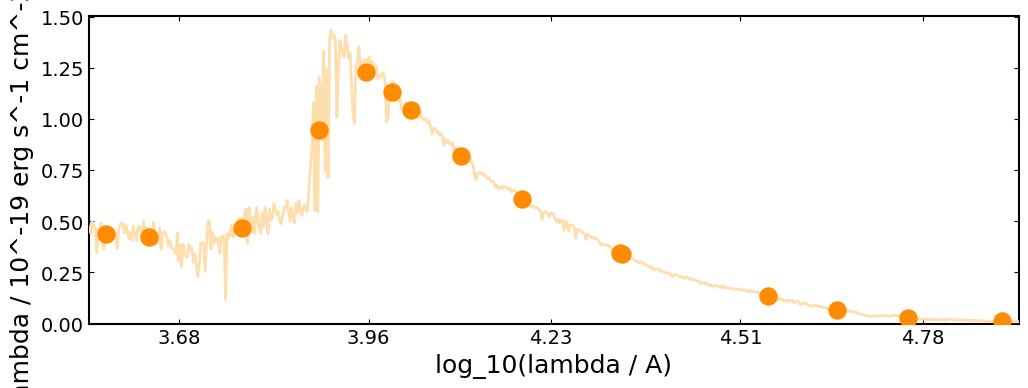

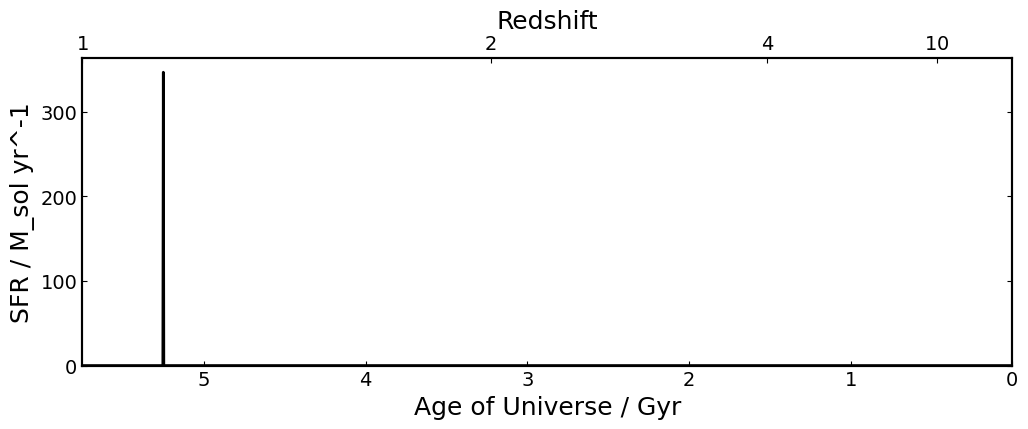

In [ ]:
fig = galaxy.model.plot()       # plots SED
fig = galaxy.model.sfh.plot()   # plots SFH (single delta burst)


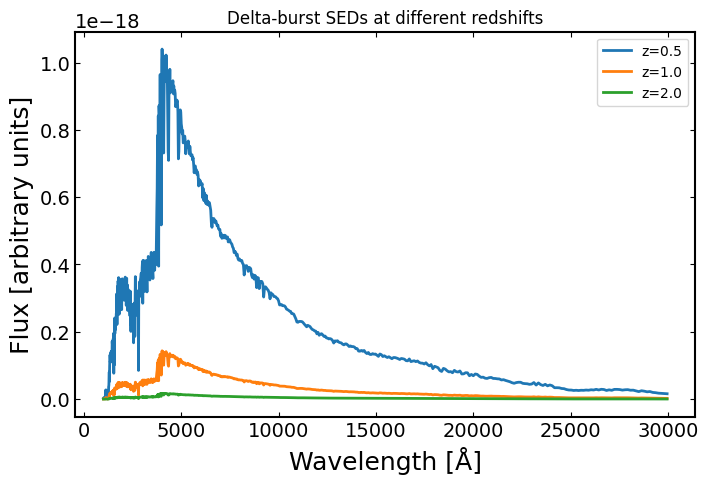

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

for z in redshifts:
    model_components["redshift"] = z
    model = pipes.model_galaxy(model_components, filt_list=goodss_filt_list)
    
    mask = (model.wavelengths > 1000) & (model.wavelengths < 30000)
    
    ax.plot(model.wavelengths[mask], model.spectrum_full[mask], label=f"z={z}")

ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel("Flux [arbitrary units]")
ax.set_title("Delta-burst SEDs at different redshifts")
ax.legend()
plt.show()
